In [6]:
import numpy as np
import matplotlib.pyplot as plt

from lib_photon import MATERIALS, calculate_attenuation_coefficients

# Material selection
material_key = 'hdpe'  # Options: 'hdpe', 'carbon', 'lead'
rho = MATERIALS[material_key]['density']   # g/cm³
data = MATERIALS[material_key]['data']
E = data[:, 0]          # Energy (MeV)
mu_over_rho = data[:, 1]  # Total mass attenuation coefficient (cm²/g)

print(f"✓ NIST XCOM data loaded from lib_photon for {MATERIALS[material_key]['name']}")


✓ Calculated mean free path for HDPE across energy range


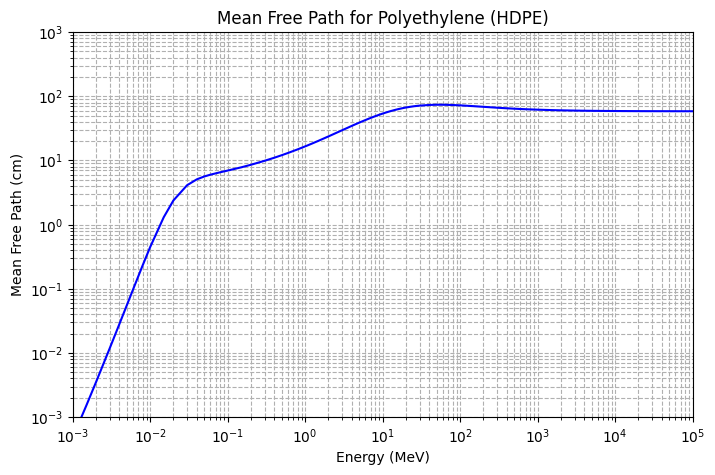

In [9]:
# mean free path as funciton of energy
mu = mu_over_rho * rho  # cm^-1
mean_free_path = 1 / mu  # cm
print("✓ Calculated mean free path for HDPE across energy range")

# plot
plt.figure(figsize=(8, 5))
plt.loglog(E, mean_free_path, marker='', linestyle='-', color='blue')
plt.title('Mean Free Path for Polyethylene (HDPE)')
plt.xlabel('Energy (MeV)')
plt.ylabel('Mean Free Path (cm)')
plt.grid(True, which='both', ls='--')
plt.xlim(1e-3, 1e5)
plt.ylim(1e-3, 1e3)
plt.show()

In [11]:
# value for 4.4 MeV gamma ray
E_gamma = 4.4  # MeV

print(f"✓ Interpolating mu/rho for {E_gamma} MeV gamma ray in HDPE...")
mu_over_rho_gamma = np.interp(E_gamma, E, mu_over_rho)
print(f"  Interpolated mu/rho: {mu_over_rho_gamma:.4e} cm²/g")
# MFP 
mu_gamma = mu_over_rho_gamma * rho  # cm^-1
range_gamma = 1 / mu_gamma  # cm
print(f"✓ Calculated range for {E_gamma} MeV gamma ray in HDPE: {range_gamma:.2f} cm")

✓ Interpolating mu/rho for 4.4 MeV gamma ray in HDPE...
  Interpolated mu/rho: 2.8960e-02 cm²/g
✓ Calculated range for 4.4 MeV gamma ray in HDPE: 36.35 cm


In [5]:
# range for a 4.4 MeV gamma ray in HDPE
E_gamma = 4.4  # MeV
mu_over_rho_gamma = np.interp(E_gamma, E, mu_over_rho)
mu_gamma = mu_over_rho_gamma * rho  # cm^-1
range_gamma = 1 / mu_gamma  # cm
print(f"✓ Calculated range for {E_gamma} MeV gamma ray in HDPE: {range_gamma:.2f} cm")


✓ Calculated range for 4.4 MeV gamma ray in HDPE: 32.05 cm
